# Customer Segmentation Using RFM Analysis and K‑Means Clustering

## 1. Business Understanding

### 1.1 Background
In the retail industry, understanding customer purchasing behavior is essential for developing effective marketing strategies and improving customer relationship management. Retail companies often have large volumes of transaction data, but without proper analysis, it is difficult to identify valuable insights about customer behavior.

One common approach to address this challenge is **customer segmentation**, which groups customers with similar purchasing patterns. By segmenting customers, businesses can better understand their customers and design targeted marketing strategies.

Customer segmentation allows companies to identify different types of customers, such as high-value customers, loyal customers, and low-engagement customers. These insights can help businesses optimize marketing efforts, improve customer retention, and allocate resources more effectively.

### 1.2 Business Problem
Retail companies often face difficulties in identifying which customers contribute the most value to the business and which customers require additional engagement strategies.

Without proper segmentation, companies may treat all customers similarly, resulting in inefficient marketing campaigns and missed opportunities for customer retention.

Therefore, the main problem addressed in this project is:

**How can customer transaction data be used to identify meaningful customer segments based on their purchasing behavior?**

### 1.3 Project Objective
The objective of this project is to perform **customer segmentation using transaction data** from an online retail dataset.

Specifically, the project aims to:

- Analyze customer purchasing behavior using **Recency, Frequency, and Monetary (RFM) analysis**
- Group customers into meaningful segments using **K-Means clustering**
- Identify customer segments based on their value and purchasing patterns
- Provide insights that can support data-driven marketing strategies

### 1.4 Analytical Approach
To solve the business problem, this project uses **RFM analysis combined with clustering techniques**.

RFM analysis evaluates customer behavior using three metrics:

- **Recency (R)** – how recently a customer made a purchase  
- **Frequency (F)** – how often a customer makes purchases  
- **Monetary (M)** – how much money a customer spends  

These metrics capture key aspects of customer purchasing behavior and are widely used in marketing analytics.

After computing the RFM features, the project applies the **K-Means clustering algorithm** to group customers into distinct segments based on their RFM characteristics.

### 1.5 Expected Business Value
The results of this analysis can provide several benefits for retail businesses:

- Identify **high-value customers** who contribute the most revenue
- Detect **loyal customers** who frequently purchase products
- Recognize **low-engagement customers** who may require targeted marketing campaigns
- Support **personalized marketing strategies**
- Improve **customer retention and lifetime value**

By leveraging these insights, companies can implement more efficient marketing strategies and build stronger relationships with their customers.

### 1.6 Success Criteria
The project will be considered successful if:

- Customers can be grouped into meaningful segments using RFM features
- The clustering model produces well-separated clusters (evaluated using clustering metrics such as silhouette score)
- Each customer segment can be clearly interpreted from a business perspective

## 2. Data Understanding

### 2.1 Dataset Loading

In [60]:
import warnings
warnings.filterwarnings("ignore")

import time
start_time = time.time()

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.stats import kruskal
import scikit_posthocs as sp

import joblib

np.random.seed(42)

real_df = pd.read_csv(
    '../datasets/online-retail-ii-cleaned.csv.zstd',
    compression='zstd',
    sep=';'
)

df = real_df.copy()

print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1033036 entries, 0 to 1033035
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   InvoiceID          1033036 non-null  str    
 1   StockCode          1033036 non-null  str    
 2   Description        1033036 non-null  str    
 3   Quantity           1033036 non-null  int64  
 4   InvoiceDate        1033036 non-null  str    
 5   Price              1033036 non-null  float64
 6   CustomerID         1033036 non-null  int64  
 7   Country            1033036 non-null  str    
 8   IsGuest            1033036 non-null  bool   
 9   Hour               1033036 non-null  int64  
 10  Year               1033036 non-null  int64  
 11  Month              1033036 non-null  int64  
 12  Day                1033036 non-null  int64  
 13  Week               1033036 non-null  int64  
 14  DayName            1033036 non-null  str    
 15  MonthName          1033036 non-null  str   

,InvoiceID,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,IsGuest,Hour,...,Week,DayName,MonthName,IsNegQty,IsNegPrice,IsCanceled,IsAdjusted,TotalPrice,IsQuantityOutlier,IsPriceOutlier
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.95,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,83.4,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,81.0,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,81.0,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01,2.10,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,100.8,True,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,30.0,True,False


The dataset used in this project is the **Online Retail II dataset**, which contains transactional records from an online retail store, including information such as invoice identifiers, product descriptions, quantities purchased, prices, transaction dates, and customer identifiers. The dataset is stored in a compressed **Zstandard (.zstd)** format to reduce storage size while maintaining efficient loading performance. After loading the dataset using the pandas library, a copy of the original dataframe is created to preserve the raw data, allowing subsequent data processing and analysis to be conducted without modifying the original dataset.

### 2.2 Missing Values and Duplicate Data Inspection

In [61]:
print("Missing Values:")
display(df.isna().sum())

print("Duplicated Rows:", df.duplicated().sum())

display(df[df.duplicated()])

Missing Values:


InvoiceID            0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
Price                0
CustomerID           0
Country              0
IsGuest              0
Hour                 0
Year                 0
Month                0
Day                  0
Week                 0
DayName              0
MonthName            0
IsNegQty             0
IsNegPrice           0
IsCanceled           0
IsAdjusted           0
TotalPrice           0
IsQuantityOutlier    0
IsPriceOutlier       0
dtype: int64

Duplicated Rows: 2


,InvoiceID,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,IsGuest,Hour,...,Week,DayName,MonthName,IsNegQty,IsNegPrice,IsCanceled,IsAdjusted,TotalPrice,IsQuantityOutlier,IsPriceOutlier
41180,492807,21813,GARLAND WITH STARS AND BELLS,6,2009-12-20,4.95,17211,United Kingdom,False,12,...,51,Sunday,December,False,False,False,False,29.7,False,False
839988,567183,22659,LUNCH BOX I LOVE LONDON,2,2011-09-18,1.95,14769,United Kingdom,False,15,...,37,Sunday,September,False,False,False,False,3.9,False,False


Before performing further data analysis and preprocessing, it is important to examine the dataset for potential data quality issues such as missing values and duplicate records. Missing value inspection helps identify whether any variables contain incomplete information that may affect subsequent analysis. Additionally, duplicate records are checked to determine whether identical rows exist in the dataset, which could lead to biased results if not handled properly. Identifying these issues at an early stage ensures that the dataset maintains good quality and reliability for further data processing and modeling.

## 3. Data Preparation

### 3.1 Duplicate Data Removal

In [62]:
df = df[~df.duplicated()]

print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


After identifying duplicate records in the dataset, the duplicated rows are removed to ensure that each transaction is represented only once. Duplicate data can distort analytical results, particularly in transaction-based analysis such as customer segmentation, because repeated records may artificially inflate purchase frequency or monetary values. Therefore, removing duplicates helps maintain data integrity and ensures that subsequent analysis is based on accurate and reliable information.

### 3.2 Data Cleaning

In [63]:
df_clean = df[
    (~df['IsNegQty']) &
    (~df['IsNegPrice']) &
    (~df['IsQuantityOutlier']) &
    (~df['IsPriceOutlier']) &
    (~df['IsGuest']) &
    (~df['IsCanceled'])
].copy()

df_clean.head()

,InvoiceID,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,IsGuest,Hour,...,Week,DayName,MonthName,IsNegQty,IsNegPrice,IsCanceled,IsAdjusted,TotalPrice,IsQuantityOutlier,IsPriceOutlier
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.95,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,83.4,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,81.0,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,81.0,False,False
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01,5.95,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,59.5,False,False
8,489435,22350,CAT BOWL,12,2009-12-01,2.55,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,30.6,False,False


To ensure the quality and reliability of the dataset, several filtering conditions are applied to remove invalid or irrelevant transaction records. Transactions with negative quantities or prices are excluded, as they may represent data entry errors or return transactions that are not relevant for this analysis. In addition, records identified as quantity or price outliers are removed to prevent extreme values from distorting the results. Transactions made by guest users are also excluded because they lack a unique customer identifier, which is necessary for customer-level analysis. Lastly, canceled transactions are filtered out to ensure that only completed purchases are included in the dataset used for further analysis.

### 3.3 RFM Feature Engineering

In [64]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceID': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346,530,11,372.86
1,12347,3,8,3309.37
2,12348,249,2,118.20
3,12349,19,3,2685.44
4,12350,311,1,274.00


In this step, customer-level features are created using the **RFM (Recency, Frequency, Monetary)** framework, which is commonly used in customer segmentation analysis. First, the transaction date column is converted into a datetime format to enable time-based calculations. A snapshot date is then defined as one day after the most recent transaction in the dataset, which serves as the reference point for calculating recency. The dataset is subsequently grouped by customer identifier to compute the three RFM metrics: **Recency**, representing the number of days since the customer's last purchase; **Frequency**, representing the number of unique transactions made by the customer; and **Monetary**, representing the total amount spent by the customer. These features summarize each customer's purchasing behavior and will be used as the primary variables for clustering analysis.

### 3.4 Log Transformation

In [65]:
rfm_log = rfm[['Recency','Frequency','Monetary']].apply(np.log1p)

display(rfm_log.describe())

,Recency,Frequency,Monetary
count,5654.000000,5654.000000,5654.000000
mean,4.482460,1.516442,6.345335
std,1.523343,0.784630,1.346892
min,0.693147,0.693147,0.000000
25%,3.332205,0.693147,5.419583
50%,4.584967,1.386294,6.333581
75%,5.942799,1.945910,7.255199
max,6.606650,5.905362,11.976064


Before performing clustering, a logarithmic transformation is applied to the RFM variables to reduce skewness in the data distribution. Transaction-related variables such as frequency and monetary values often exhibit highly right-skewed distributions due to the presence of a small number of customers with very high purchase activity. The `log1p` transformation is used to stabilize variance and compress extreme values while preserving zero values in the dataset. This transformation helps produce a more balanced feature distribution, which improves the performance and stability of clustering algorithms.

### 3.5 RFM Distribution Analysis

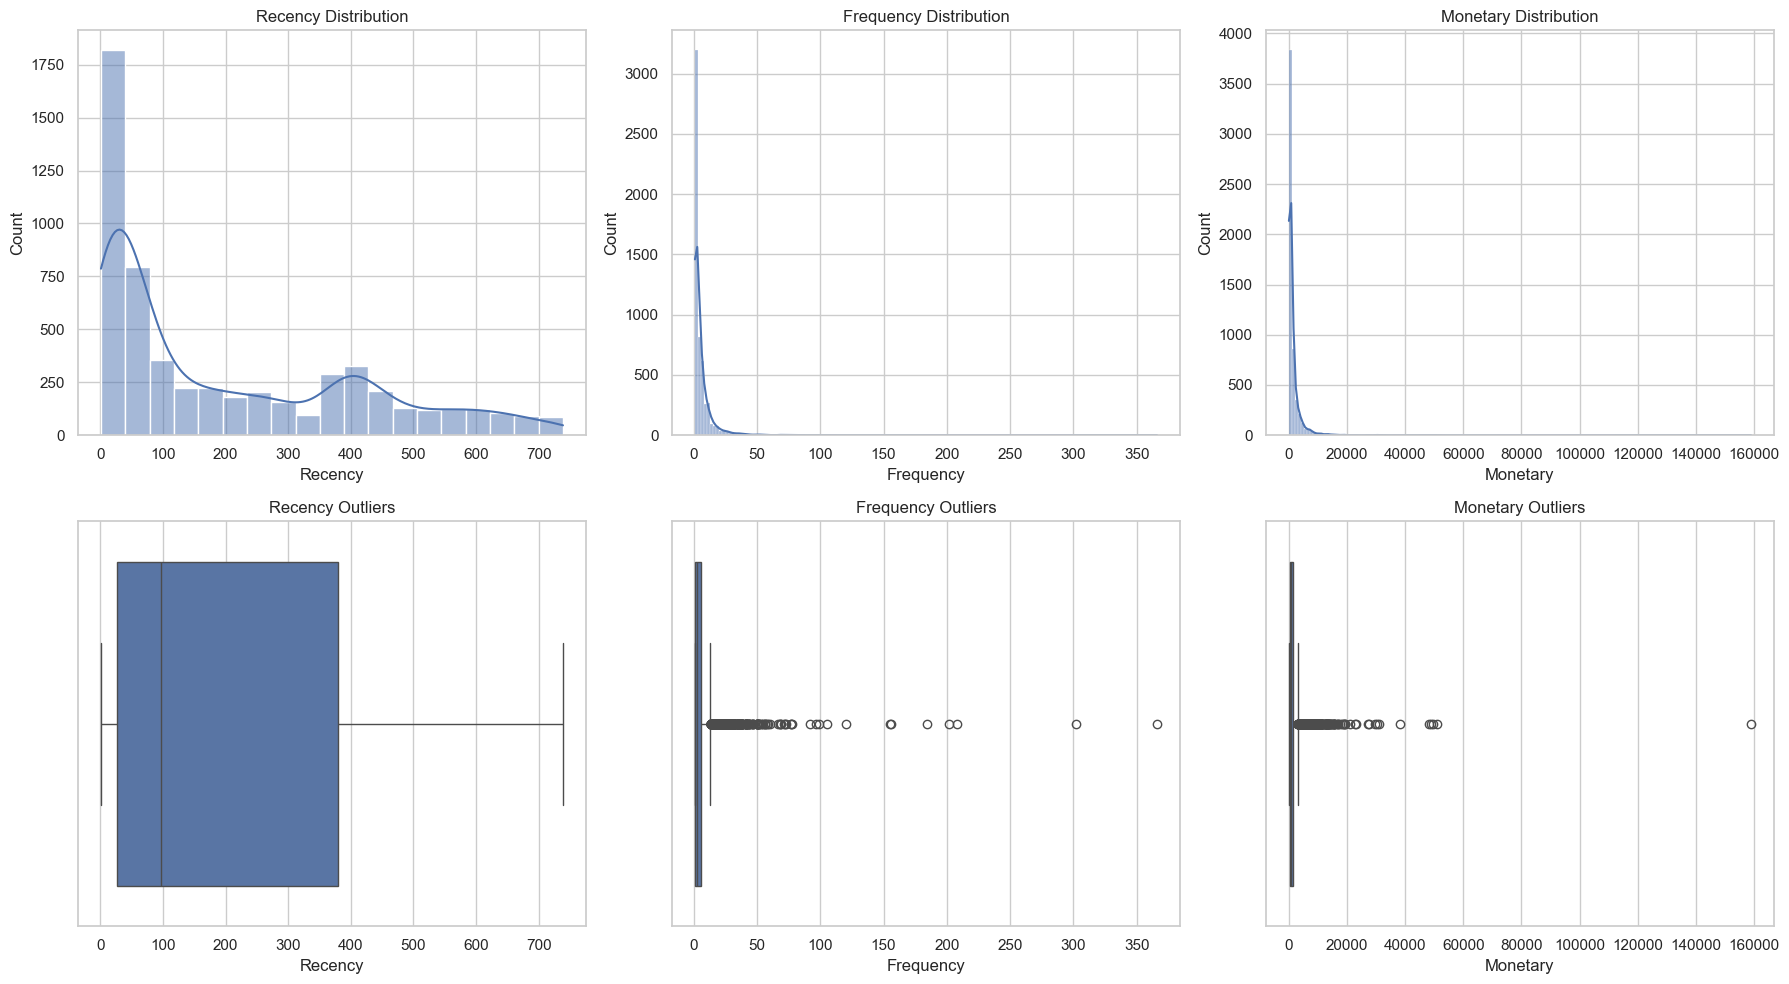

In [66]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(2,3, figsize=(18,10))
features = ['Recency','Frequency','Monetary']

for i,col in enumerate(features):

    sns.histplot(rfm[col], kde=True, ax=ax[0,i])
    ax[0,i].set_title(f"{col} Distribution")

    sns.boxplot(x=rfm[col], ax=ax[1,i])
    ax[1,i].set_title(f"{col} Outliers")

plt.tight_layout()
plt.show()

To better understand the characteristics of the RFM variables, the distributions of **Recency**, **Frequency**, and **Monetary** are visualized using histograms and boxplots. Histograms provide an overview of how the values are distributed across customers, while boxplots help identify the presence of potential outliers. This analysis is important because transaction-related variables typically exhibit skewed distributions and extreme values. By examining these visualizations, it becomes easier to assess the overall data distribution and determine whether transformations or scaling techniques are necessary before applying clustering algorithms.

### 3.6 Correlation Analysis

Spearman Correlation:


,Recency,Frequency,Monetary
Recency,1.000000,-0.554426,-0.509993
Frequency,-0.554426,1.000000,0.848462
Monetary,-0.509993,0.848462,1.000000


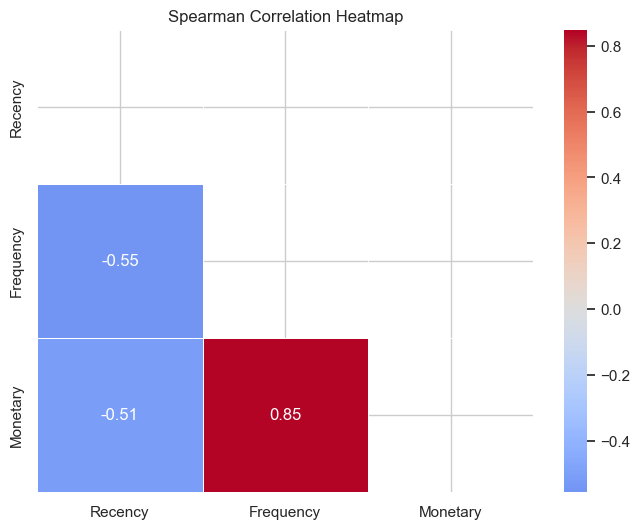

In [67]:
spearman_corr = rfm[['Recency','Frequency','Monetary']].corr(method='spearman')

print("Spearman Correlation:")
display(spearman_corr)

plt.figure(figsize=(8,6))

mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0,
    linewidths=.5
)

plt.title("Spearman Correlation Heatmap")
plt.show()

To examine the relationships between the RFM variables, a correlation analysis is performed using the **Spearman correlation coefficient**. Spearman correlation is used instead of Pearson correlation because the RFM variables often exhibit non-normal and skewed distributions. This method measures the strength and direction of monotonic relationships between variables based on their ranked values. The resulting correlation matrix is visualized using a heatmap to provide a clearer interpretation of the relationships among Recency, Frequency, and Monetary. Understanding these relationships helps reveal patterns in customer purchasing behavior and provides additional insights before performing clustering analysis.

### 3.7 Distribution Analysis After Log Transformation

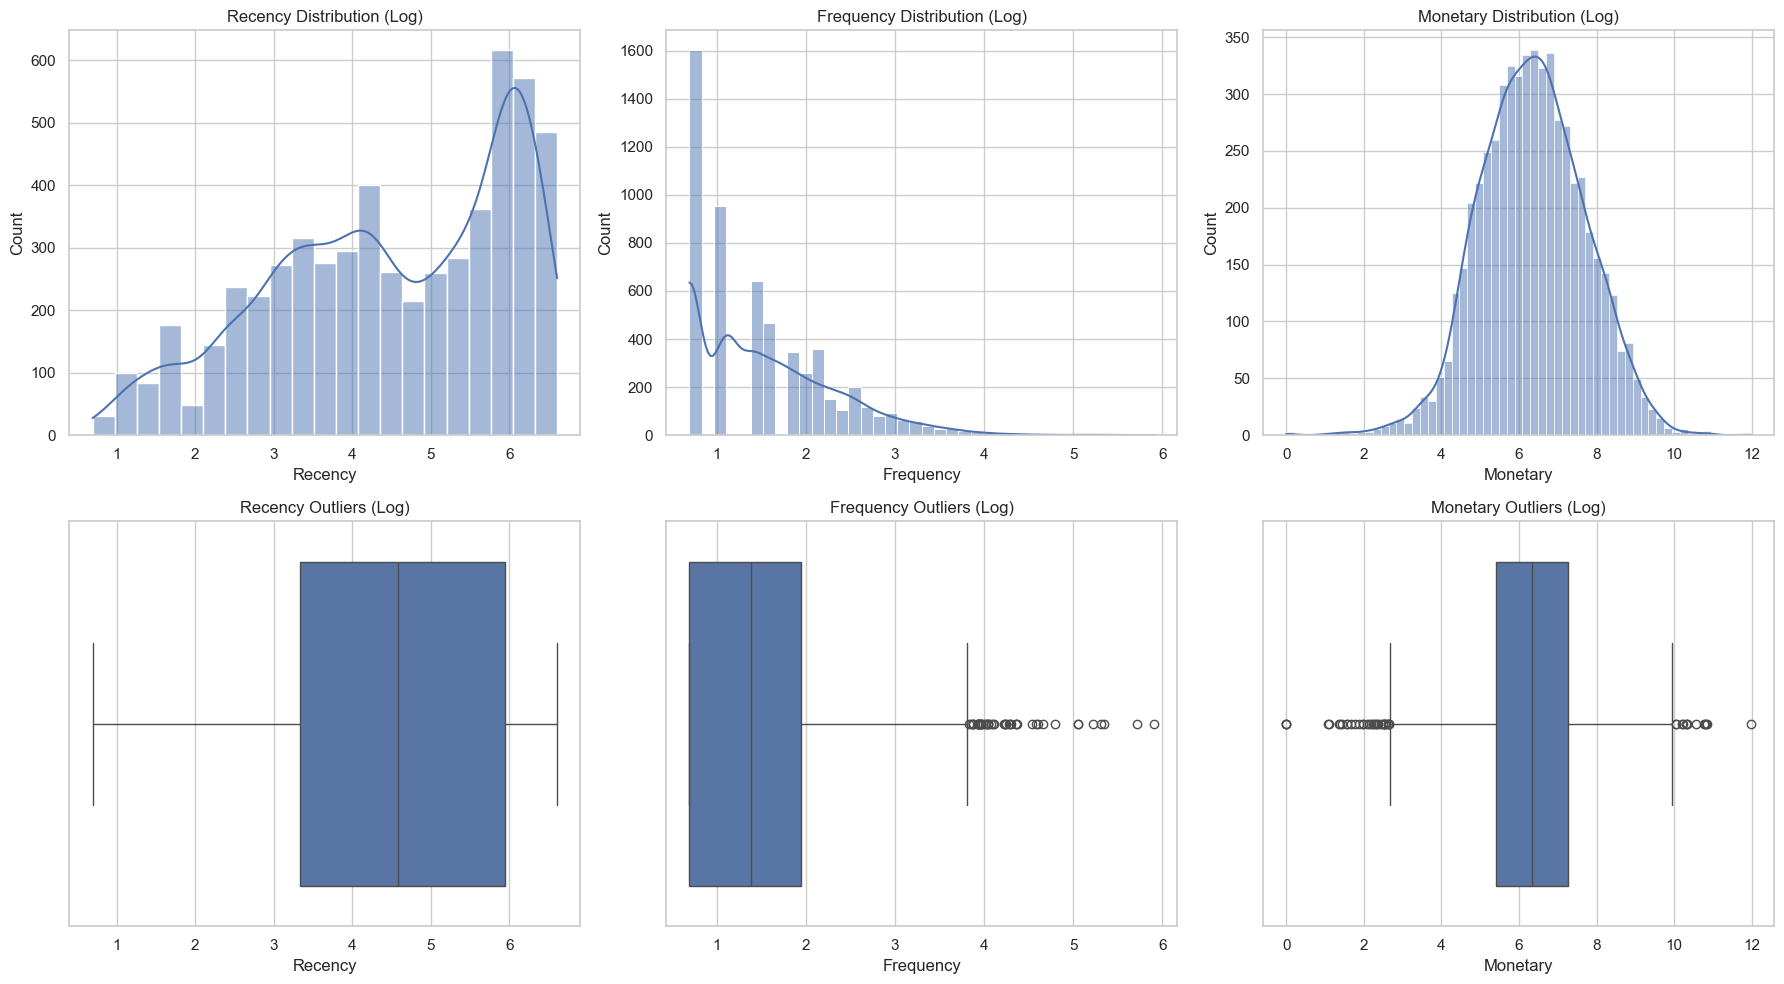

In [68]:
fig, ax = plt.subplots(2,3, figsize=(18,10))

for i,col in enumerate(features):

    sns.histplot(rfm_log[col], kde=True, ax=ax[0,i])
    ax[0,i].set_title(f"{col} Distribution (Log)")

    sns.boxplot(x=rfm_log[col], ax=ax[1,i])
    ax[1,i].set_title(f"{col} Outliers (Log)")

plt.tight_layout()
plt.show()

After applying the logarithmic transformation to the RFM variables, the distributions are visualized again using histograms and boxplots. This step aims to evaluate how the transformation affects the distribution of the data. Log transformation typically reduces skewness and compresses extreme values, making the distribution more balanced. By comparing the visualizations before and after the transformation, it becomes easier to confirm whether the transformation successfully stabilizes the data and makes it more suitable for clustering analysis.

### 3.8 Feature Scaling

In [69]:
scaler = RobustScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

df_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency','Frequency','Monetary']
)

display(df_scaled.head())

,Recency,Frequency,Monetary
0,0.647283,0.876951,-0.223195
1,-1.225266,0.647313,0.964926
2,0.358728,-0.229638,-0.845917
3,-0.608764,0.000000,0.851153
4,0.443591,-0.553295,-0.390501


Before applying the clustering algorithm, the RFM features are scaled to ensure that each variable contributes equally to the distance calculations used by the model. In this project, **RobustScaler** is applied because it is less sensitive to extreme values compared to standard scaling methods. RobustScaler scales the data using the median and interquartile range (IQR), making it more suitable for datasets that may still contain outliers even after transformation. The scaled features are then stored in a new dataframe to be used as input for the clustering process.

## 4. Modeling

### 4.1 Elbow Method -> Determining the Optimal Number of Clusters

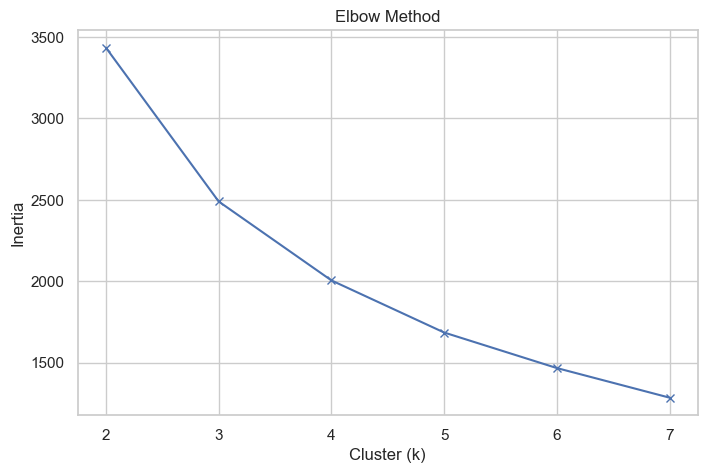

In [70]:
inertia = []
K = range(2,8)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(df_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, 'bx-')
plt.xlabel("Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Before applying the clustering algorithm, it is necessary to determine the appropriate number of clusters. In this step, the **Elbow Method** is used to evaluate how the clustering performance changes as the number of clusters increases. The method measures the **inertia**, which represents the within-cluster sum of squared distances between data points and their respective cluster centroids. As the number of clusters increases, inertia typically decreases because data points become closer to their assigned centroids. The optimal number of clusters is identified at the point where the rate of decrease in inertia begins to slow down significantly, forming an "elbow" shape in the plot. This point indicates a balance between model simplicity and clustering performance.

### 4.2 Silhouette Score Evaluation

In [71]:
k_range = range(2,8)

results = []

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)

    results.append({
        "k": k,
        "silhouette_score": score
    })

silhouette_df = pd.DataFrame(results)

# sort dari terbaik
silhouette_df = silhouette_df.sort_values(
    by="silhouette_score",
    ascending=False
).reset_index(drop=True)

display(silhouette_df)

,k,silhouette_score
0,2,0.438721
1,4,0.356633
2,3,0.351653
3,5,0.323603
4,7,0.305443
5,6,0.297589


In addition to the Elbow Method, the **Silhouette Score** is used to evaluate the quality of clustering for different numbers of clusters. The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters. It considers both **cluster cohesion** (how close points are within the same cluster) and **cluster separation** (how distinct clusters are from each other). The score ranges from **-1 to 1**, where higher values indicate better-defined and more separated clusters. By calculating the silhouette score for multiple cluster values, it becomes possible to identify the number of clusters that produces the most meaningful segmentation.

### 4.3 K-Means Clustering

In [72]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster_Raw'] = kmeans.fit_predict(df_scaled)

cluster_colors = {
    'Platinum':'#E5E4E2',
    'Gold':'#FFD700',
    'Silver':'#C0C0C0',
    'Bronze':'#CD7F32'
}

After determining the optimal number of clusters, the **K-Means clustering algorithm** is applied to segment customers based on their RFM characteristics. In this step, the number of clusters is set to four, which represents four different customer segments. The model assigns each customer to a cluster by minimizing the distance between the data points and their corresponding cluster centroids in the scaled RFM feature space. The resulting cluster labels are stored in a new column called `Cluster_Raw`. Additionally, a color mapping is defined for each customer segment to facilitate consistent visualization in later analyses.

### 4.4 Cluster Labeling and Distribution

,Recency,Frequency,Monetary
,median,median,median
Cluster,,,
Bronze,397.0,1.0,166.445
Silver,24.0,3.0,524.650
Gold,206.5,4.0,861.845
Platinum,19.0,12.0,3135.070


,Customers,Percentage (%)
Cluster,,
Bronze,1882,33.29
Silver,1165,20.60
Gold,1426,25.22
Platinum,1181,20.89


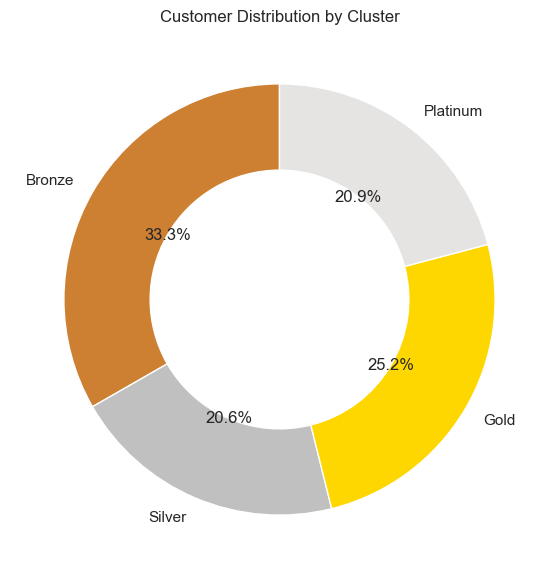

In [73]:
cluster_ordered = (
    rfm.groupby('Cluster_Raw')['Monetary']
    .median()
    .sort_values()
    .index
)

rfm_map = {
    cluster_id:name
    for cluster_id,name
    in zip(cluster_ordered,["Bronze","Silver","Gold","Platinum"])
}

rfm['Cluster'] = rfm['Cluster_Raw'].map(rfm_map)

rfm['Cluster'] = pd.Categorical(
    rfm['Cluster'],
    categories=['Bronze','Silver','Gold','Platinum'],
    ordered=True
)

display(
    rfm.groupby('Cluster')[['Recency','Frequency','Monetary']]
    .agg(['median'])
)

cluster_size = (
    rfm['Cluster']
    .value_counts()
    .sort_index()
    .to_frame(name="Customers")
)

cluster_size["Percentage (%)"] = (
    cluster_size["Customers"] / cluster_size["Customers"].sum() * 100
).round(2)

display(cluster_size)


# Pie / Donut Chart
plt.figure(figsize=(7,7))

plt.pie(
    cluster_size["Customers"],
    labels=cluster_size.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[cluster_colors[c] for c in cluster_size.index],
    wedgeprops=dict(width=0.4)  # donut style
)

plt.title("Customer Distribution by Cluster")

plt.show()

After the clustering process, the raw cluster labels generated by the K-Means algorithm are interpreted to provide meaningful business-oriented segment names. The clusters are ranked based on the **median monetary value**, which reflects the typical spending behavior of customers in each cluster. Based on this ranking, the clusters are mapped into four customer segments: **Bronze, Silver, Gold, and Platinum**, representing increasing levels of customer value. This labeling approach helps translate the clustering results into interpretable categories that align with common marketing segmentation practices. Additionally, the distribution of customers across these segments is calculated and visualized using a donut chart to provide an overview of the proportion of customers in each segment.

## 5. Evaluation

### 5.1 Cluster Profiling

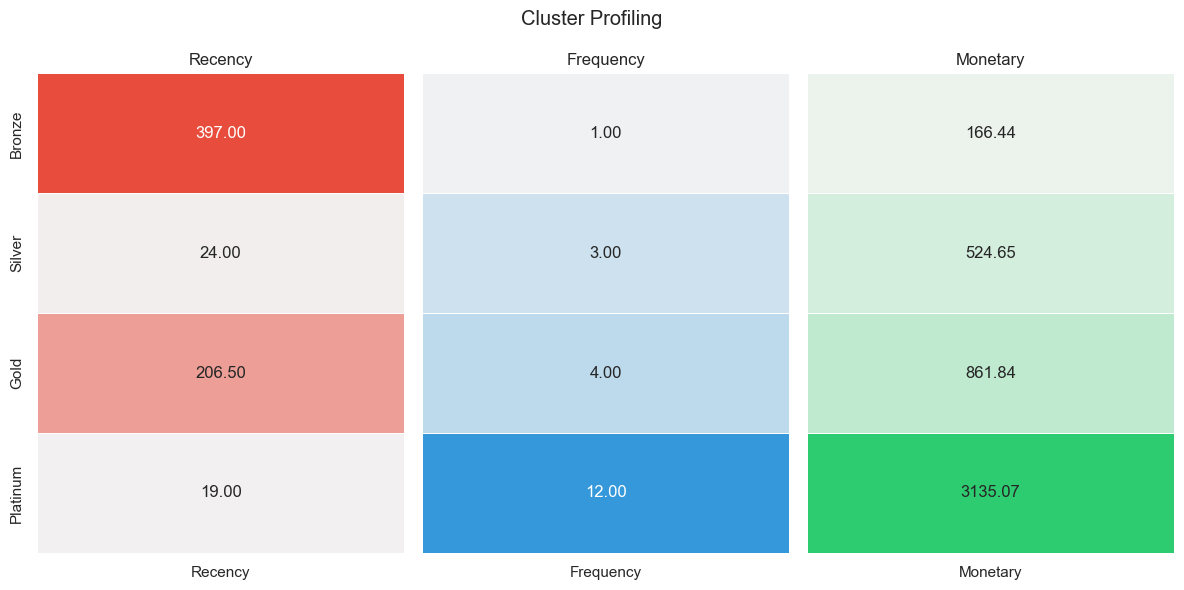

Bronze customers: median Recency 397 days, 1 purchases, $166 spending.
Silver customers: median Recency 24 days, 3 purchases, $525 spending.
Gold customers: median Recency 206 days, 4 purchases, $862 spending.
Platinum customers: median Recency 19 days, 12 purchases, $3135 spending.


In [74]:
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency':'median',
    'Frequency':'median',
    'Monetary':['median','count']
}).round(2)

heatmap_data = cluster_analysis.drop(columns=('Monetary','count'))
heatmap_data.columns = ['Recency','Frequency','Monetary']

cluster_order = ["Bronze", "Silver", "Gold", "Platinum"]
heatmap_data = heatmap_data.reindex(cluster_order)

fig, axes = plt.subplots(1,3, figsize=(12,6), sharey=True)

palettes = {
    "Recency": sns.light_palette("#e74c3c", as_cmap=True),
    "Frequency": sns.light_palette("#3498db", as_cmap=True),
    "Monetary": sns.light_palette("#2ecc71", as_cmap=True)
}

for i, col in enumerate(heatmap_data.columns):

    data_col = heatmap_data[[col]]

    norm = (data_col - data_col.min()) / (data_col.max() - data_col.min())

    sns.heatmap(
        norm,
        annot=data_col,
        fmt=".2f",
        cmap=palettes[col],
        linewidths=.5,
        cbar=False,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")  # hapus tulisan "Cluster"

plt.suptitle("Cluster Profiling")

plt.tight_layout()

plt.savefig(
    "../outputs/rfm_cluster_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

for cluster in heatmap_data.index:
    r = heatmap_data.loc[cluster, "Recency"]
    f = heatmap_data.loc[cluster, "Frequency"]
    m = heatmap_data.loc[cluster, "Monetary"]

    print(f"{cluster} customers: median Recency {r:.0f} days, "
          f"{f:.0f} purchases, ${m:.0f} spending.")

To better understand the characteristics of each customer segment, a cluster profiling analysis is conducted using the median values of the RFM variables. For each cluster, the median **Recency**, **Frequency**, and **Monetary** values are calculated to represent the typical purchasing behavior of customers within that segment. These metrics provide insights into how recently customers made purchases, how frequently they buy, and how much they typically spend. The results are visualized using heatmaps to highlight differences across clusters, making it easier to compare customer segments. This profiling step helps translate the clustering results into meaningful business insights that can support marketing strategies and customer relationship management.

### 5.2 Statistical Validation

In [75]:
metrics = ['Recency','Frequency','Monetary']

results = []

for metric in metrics:

    print(f"\nKruskal–Wallis Test for {metric}")
    print(f"H0 : Median {metric} is equal across clusters")
    print(f"H1 : Median {metric} differs in at least one cluster")
    print("Significance level (α) = 0.05")

    groups = [
        rfm[rfm['Cluster']==c][metric]
        for c in rfm['Cluster'].cat.categories
    ]

    stat, p_value = kruskal(*groups)

    decision = "Reject H0" if p_value < 0.05 else "Fail to Reject H0"

    print(f"Statistic = {stat:.3f}")
    print(f"p-value = {p_value:.4e}")
    print(f"Decision = {decision}")

    results.append({
        "Metric": metric,
        "Statistic": round(stat,3),
        "p_value": p_value,
        "Decision": decision
    })

kruskal_df = pd.DataFrame(results)
display(kruskal_df)


Kruskal–Wallis Test for Recency
H0 : Median Recency is equal across clusters
H1 : Median Recency differs in at least one cluster
Significance level (α) = 0.05
Statistic = 3860.191
p-value = 0.0000e+00
Decision = Reject H0

Kruskal–Wallis Test for Frequency
H0 : Median Frequency is equal across clusters
H1 : Median Frequency differs in at least one cluster
Significance level (α) = 0.05
Statistic = 4224.691
p-value = 0.0000e+00
Decision = Reject H0

Kruskal–Wallis Test for Monetary
H0 : Median Monetary is equal across clusters
H1 : Median Monetary differs in at least one cluster
Significance level (α) = 0.05
Statistic = 4438.236
p-value = 0.0000e+00
Decision = Reject H0


,Metric,Statistic,p_value,Decision
0,Recency,3860.191,0.0,Reject H0
1,Frequency,4224.691,0.0,Reject H0
2,Monetary,4438.236,0.0,Reject H0


To statistically validate the differences between customer segments, the **Kruskal–Wallis test** is applied to the RFM variables. This non-parametric test is used to determine whether the median values of **Recency, Frequency, and Monetary** differ significantly across the clusters. The Kruskal–Wallis test is appropriate in this context because it does not assume normal data distribution and is suitable for comparing more than two independent groups. The null hypothesis states that the median values of the variable are equal across all clusters, while the alternative hypothesis suggests that at least one cluster differs. A significance level of **0.05** is used to determine statistical significance. If the p-value is less than 0.05, the null hypothesis is rejected, indicating that the clusters exhibit statistically significant differences in the respective RFM metric.

### 5.3 Cluster Visualization

In [76]:
rfm[['R_scaled','F_scaled','M_scaled']] = df_scaled

fig = px.scatter_3d(
    rfm,
    x='R_scaled',
    y='F_scaled',
    z='M_scaled',
    color='Cluster',
    color_discrete_map=cluster_colors,
    opacity=0.5,
    title="Customer Segmentation (Scaled RFM Space)",

    hover_data={
        'CustomerID': True,
        'Recency': True,
        'Frequency': True,
        'Monetary': True,
        'R_scaled': False,
        'F_scaled': False,
        'M_scaled': False
    }
)

fig.update_layout(
    template='plotly_dark',
    margin=dict(l=0,r=0,b=0,t=40),

    scene=dict(
        xaxis_title="Recency (days)",
        yaxis_title="Frequency (purchases)",
        zaxis_title="Monetary ($)"
    )
)

fig.show()

To visually explore the clustering results, a **three-dimensional scatter plot** is created using the scaled RFM features. Each data point represents a customer, positioned according to their scaled **Recency, Frequency, and Monetary** values. The points are colored based on their assigned cluster to clearly distinguish the customer segments. This visualization helps illustrate how customers are distributed across the feature space and provides an intuitive view of the separation between clusters. Interactive visualization with Plotly also allows additional information, such as customer ID and original RFM values, to be displayed when hovering over individual data points.

## 6. Deployment

### 6.1 Exporting Analysis Results

In [77]:
rfm.to_csv(
    '../outputs/rfm_customer_segmentation.csv',
    index=False
)

cluster_analysis.to_csv(
    '../outputs/rfm_cluster_profile.csv'
)

print("Files exported")

Files exported


After completing the clustering and profiling analysis, the results are exported as CSV files for further use outside the analysis environment. The first file contains the customer-level segmentation results, including the assigned cluster for each customer. The second file stores the aggregated cluster profile, summarizing the median RFM values and customer counts for each segment. Exporting these outputs enables the results to be easily shared, integrated into dashboards, or used for further business analysis and reporting.

### 6.2 Model Artifact Saving

In [78]:
joblib.dump(kmeans,"../outputs/kmeans_rfm_model.pkl")
joblib.dump(scaler,"../outputs/rfm_scaler.pkl")
joblib.dump(rfm_map,"../outputs/rfm_cluster_map.pkl")

print("Model artifacts saved")

Model artifacts saved


To enable future reuse of the trained model, several model artifacts are saved after the clustering process is completed. These artifacts include the trained **K-Means model**, the **feature scaler**, and the **cluster label mapping** used to translate raw cluster indices into meaningful segment names. Saving these components allows the segmentation pipeline to be reproduced without retraining the model and enables the model to be applied to new customer data in production or future analyses.

## 7. Inference

### 7.1 Customer Cluster Prediction

In [79]:
kmeans_loaded = joblib.load("../outputs/kmeans_rfm_model.pkl")
scaler_loaded = joblib.load("../outputs/rfm_scaler.pkl")
rfm_map_loaded = joblib.load("../outputs/rfm_cluster_map.pkl")

new_customer = pd.DataFrame({
    "Recency":[10],
    "Frequency":[5],
    "Monetary":[120]
})

new_customer_log = np.log1p(new_customer)

new_customer_scaled = scaler_loaded.transform(new_customer_log)

cluster_id = kmeans_loaded.predict(new_customer_scaled)[0]

cluster_name = rfm_map_loaded.get(cluster_id,"Unknown")

print("Customer cluster:", cluster_name)

Customer cluster: Silver


To demonstrate the practical use of the trained clustering model, a prediction example is performed using a new customer's RFM data. The previously saved model artifacts, including the trained K-Means model, the feature scaler, and the cluster label mapping, are first loaded. The new customer's RFM values are then processed using the same preprocessing steps applied during model training, including logarithmic transformation and feature scaling. After preprocessing, the K-Means model predicts the cluster assignment for the new customer. The predicted cluster index is then mapped to its corresponding customer segment label, providing an interpretable classification of the customer's value category.

### 7.2 Execution Time Measurement

In [80]:
end_time = time.time()

total_time = end_time - start_time

print(f"Total runtime: {total_time:.2f} seconds")

Total runtime: 6.02 seconds


To monitor the computational performance of the analysis pipeline, the total execution time of the script is measured. The timer starts at the beginning of the process and ends after all analysis steps have been completed. The difference between the start and end times represents the total runtime required to execute the entire workflow. Measuring execution time helps evaluate the efficiency of the pipeline and provides useful information for optimizing performance when working with larger datasets or deploying the model in production environments.

## 8. Conclusion and Recommendations

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Proin volutpat, ligula eu sollicitudin feugiat, justo eros varius nisl, id tempor felis dolor et dui. Cras mollis scelerisque tempor. Praesent dignissim elit convallis tempor pharetra. Pellentesque sagittis, lectus a semper mollis, nulla nibh fermentum dui, vitae feugiat felis libero vel nulla. Quisque laoreet placerat urna non cursus. Nullam commodo, metus lobortis varius malesuada, magna sapien aliquet orci, sit amet fringilla risus quam sit amet sem. Sed id est ac purus rutrum porta. Suspendisse sed neque nisi. Fusce dignissim ipsum at dolor efficitur rhoncus. Nullam et arcu eu lectus pretium commodo eget in orci. Proin consequat vel purus at aliquet. Sed ac sem eleifend, tincidunt tellus eu, feugiat sem. Aliquam dapibus diam eu lectus rutrum finibus.